# Visualisations pour la pr\u00e9diction TMRT


Ce notebook regroupe les figures utiles pour pr\u00e9senter la partie pr\u00e9diction du semestre 2. Il ne lance pas de script externe : chaque figure est construite ici, \u00e0 partir des tableaux export\u00e9s par `Prediction.ipynb`.

L'objectif est de garder des graphiques simples et lisibles, dans le m\u00eame esprit que les figures d'analyse exploratoire : fond blanc, titres courts, couleurs sobres et sorties en `dpi=150`.


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed" / "prediction"
REPORT_DIR = DATA_DIR / "tmrt_pred_report"
EVAL_DIR = DATA_DIR / "eval"
BIAS_DIR = DATA_DIR / "biais"
NO_IID_DIR = DATA_DIR / "no_iid"

FIG_ROOT = ROOT / "prediction" / "figures"
FIG_PRED_DATA = FIG_ROOT / "prediction_data"
FIG_EVAL = FIG_ROOT / "eval"
FIG_BIAS = FIG_ROOT / "biais"
FIG_MODEL = FIG_ROOT / "model_analysis"
FIG_NO_IID = FIG_ROOT / "no_iid"

for folder in [FIG_PRED_DATA, FIG_EVAL, FIG_BIAS, FIG_MODEL, FIG_NO_IID]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
RED = "#d62728"
GREY = "#666666"
TRACK_ORDER = ["antigone", "boulevards", "ecusson"]
MSLOT_ORDER = ["M1", "M2", "M3", "M4"]
SPLIT_ORDER = ["random_naive", "spatial_section_group", "passage_group", "leave_one_track_out", "date_group"]

GENERATED_FIGURES = []


def rel(path):
    path = Path(path)
    try:
        return path.relative_to(ROOT)
    except ValueError:
        return path


def save_figure(fig, path, extra_paths=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    GENERATED_FIGURES.append(path)

    for extra_path in extra_paths or []:
        extra_path = Path(extra_path)
        extra_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(extra_path, dpi=150, bbox_inches="tight")
        GENERATED_FIGURES.append(extra_path)

    plt.show()
    print("Figure enregistr\u00e9e :", rel(path))
    if extra_paths:
        for extra_path in extra_paths:
            print("Copie enregistr\u00e9e :", rel(extra_path))


def ordered_existing(values, preferred):
    values = [v for v in preferred if v in set(values)]
    return values


def numeric_columns(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def read_csv_if_exists(path, **kwargs):
    path = Path(path)
    if not path.exists():
        print("Fichier absent :", rel(path))
        return pd.DataFrame()
    return pd.read_csv(path, **kwargs)


## Chargement des donn\u00e9es

On repart des exports disponibles dans `data/processed/prediction/`. Le tableau principal contient les observations TMRT et les pr\u00e9dictions associ\u00e9es. Les autres fichiers servent \u00e0 analyser les performances, les biais et la structure des groupes de passage.


In [2]:
df_pred = read_csv_if_exists(DATA_DIR / "tmrt_predictions_grid_or_points.csv")
test_rows = read_csv_if_exists(REPORT_DIR / "tmrt_pred_MF_plus_AE_raw64.csv")

if test_rows.empty:
    test_rows = read_csv_if_exists(
        REPORT_DIR / "tmrt_pred_testrows_MF_plus_AE_raw64.csv",
        sep=";",
        decimal=",",
    )

model_comparison = read_csv_if_exists(EVAL_DIR / "model_comparison.csv")
metrics_all = read_csv_if_exists(EVAL_DIR / "evaluation_metrics_all_splits.csv")
metrics_by_group = read_csv_if_exists(EVAL_DIR / "evaluation_metrics_by_group.csv")
bias_analysis = read_csv_if_exists(BIAS_DIR / "bias_analysis.csv")
no_iid_diag = read_csv_if_exists(NO_IID_DIR / "diagnostics.csv")
group_errors = read_csv_if_exists(REPORT_DIR / "tmrt_pred_error_by_groups.csv")

for frame in [df_pred, test_rows, group_errors, metrics_all, metrics_by_group, bias_analysis, model_comparison]:
    if not frame.empty:
        numeric_columns(
            frame,
            [
                "tmrt", "tmrt_pred", "err", "mae", "rmse", "r2", "bias",
                "mae_mean", "rmse_mean", "r2_mean", "bias_mean",
                "bias_mean_pred_minus_obs", "median_error_pred_minus_obs",
                "n", "n_rows", "n_test", "n_test_total",
                "bias_ci95_low_group_bootstrap", "bias_ci95_high_group_bootstrap",
            ],
        )
        if "err" not in frame.columns and {"tmrt", "tmrt_pred"}.issubset(frame.columns):
            frame["err"] = frame["tmrt_pred"] - frame["tmrt"]

analysis_df = df_pred if not df_pred.empty else test_rows

resume = []
for name, frame in [
    ("pr\u00e9dictions", df_pred),
    ("lignes avec erreur", test_rows),
    ("comparaison des splits", model_comparison),
    ("m\u00e9triques par groupe", metrics_by_group),
    ("biais", bias_analysis),
    ("diagnostic non-iid", no_iid_diag),
]:
    resume.append({"table": name, "lignes": len(frame), "colonnes": len(frame.columns) if not frame.empty else 0})

display(pd.DataFrame(resume))


,table,lignes,colonnes
0,prédictions,341281,11
1,lignes avec erreur,341281,10
2,comparaison des splits,14,12
3,métriques par groupe,698,12
4,biais,28,13
5,diagnostic non-iid,30,5


## 1. Donn\u00e9es utilis\u00e9es pour la pr\u00e9diction

Avant d'analyser les scores, on v\u00e9rifie ce que le mod\u00e8le voit : distribution de la TMRT, diff\u00e9rences entre parcours, cr\u00e9neaux horaires et coh\u00e9rence globale entre observation et pr\u00e9diction.


C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\3661194279.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(values, labels=tracks, showfliers=False)
C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\3661194279.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(values, labels=slots, showfliers=False)


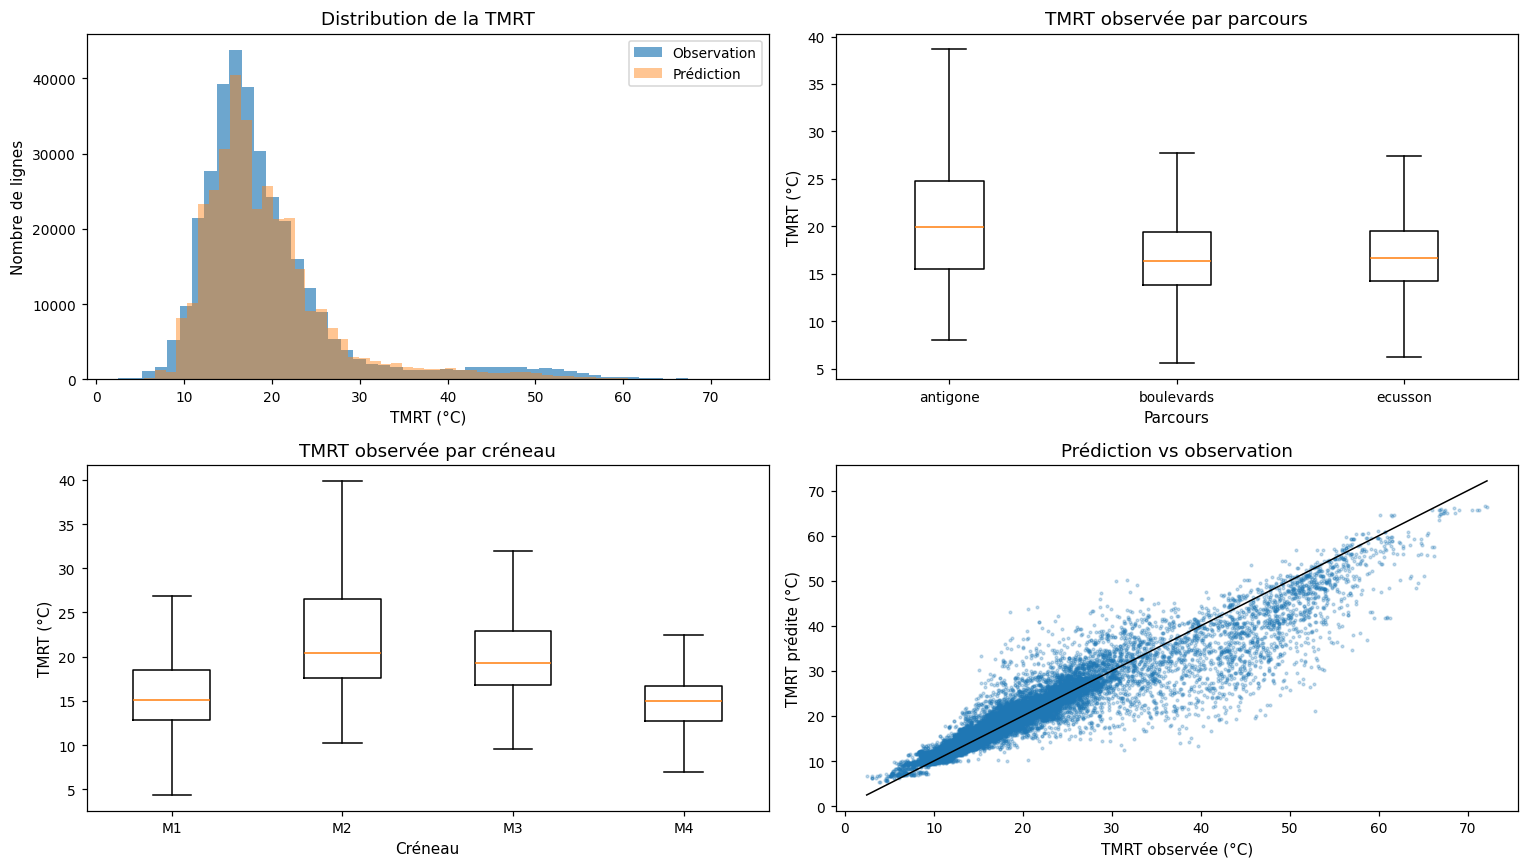

Figure enregistrée : prediction\figures\prediction_data\prediction_data_overview.png


In [3]:
if analysis_df.empty or not {"tmrt", "tmrt_pred"}.issubset(analysis_df.columns):
    print("Donn\u00e9es insuffisantes pour produire la vue d'ensemble.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    obs = analysis_df["tmrt"].dropna()
    pred = analysis_df["tmrt_pred"].dropna()

    axes[0, 0].hist(obs, bins=50, alpha=0.65, label="Observation", color=BLUE)
    axes[0, 0].hist(pred, bins=50, alpha=0.45, label="Pr\u00e9diction", color=ORANGE)
    axes[0, 0].set_title("Distribution de la TMRT")
    axes[0, 0].set_xlabel("TMRT (\u00b0C)")
    axes[0, 0].set_ylabel("Nombre de lignes")
    axes[0, 0].legend()

    if "track_id" in analysis_df.columns:
        tracks = ordered_existing(analysis_df["track_id"].dropna().unique(), TRACK_ORDER)
        values = [analysis_df.loc[analysis_df["track_id"].eq(track), "tmrt"].dropna() for track in tracks]
        axes[0, 1].boxplot(values, labels=tracks, showfliers=False)
        axes[0, 1].set_title("TMRT observ\u00e9e par parcours")
        axes[0, 1].set_xlabel("Parcours")
        axes[0, 1].set_ylabel("TMRT (\u00b0C)")
    else:
        axes[0, 1].axis("off")

    if "M_slot" in analysis_df.columns:
        slots = ordered_existing(analysis_df["M_slot"].dropna().unique(), MSLOT_ORDER)
        values = [analysis_df.loc[analysis_df["M_slot"].eq(slot), "tmrt"].dropna() for slot in slots]
        axes[1, 0].boxplot(values, labels=slots, showfliers=False)
        axes[1, 0].set_title("TMRT observ\u00e9e par cr\u00e9neau")
        axes[1, 0].set_xlabel("Cr\u00e9neau")
        axes[1, 0].set_ylabel("TMRT (\u00b0C)")
    else:
        axes[1, 0].axis("off")

    sample = analysis_df.dropna(subset=["tmrt", "tmrt_pred"]).sample(
        n=min(30000, len(analysis_df.dropna(subset=["tmrt", "tmrt_pred"]))),
        random_state=42,
    )
    axes[1, 1].scatter(sample["tmrt"], sample["tmrt_pred"], s=3, alpha=0.25, color=BLUE)
    low = min(sample["tmrt"].min(), sample["tmrt_pred"].min())
    high = max(sample["tmrt"].max(), sample["tmrt_pred"].max())
    axes[1, 1].plot([low, high], [low, high], color="black", linewidth=1)
    axes[1, 1].set_title("Pr\u00e9diction vs observation")
    axes[1, 1].set_xlabel("TMRT observ\u00e9e (\u00b0C)")
    axes[1, 1].set_ylabel("TMRT pr\u00e9dite (\u00b0C)")

    save_figure(fig, FIG_PRED_DATA / "prediction_data_overview.png")


C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\3675745059.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=slots, showfliers=False)
C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\3675745059.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=slots, showfliers=False)
C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\3675745059.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=slots, showfliers=False)


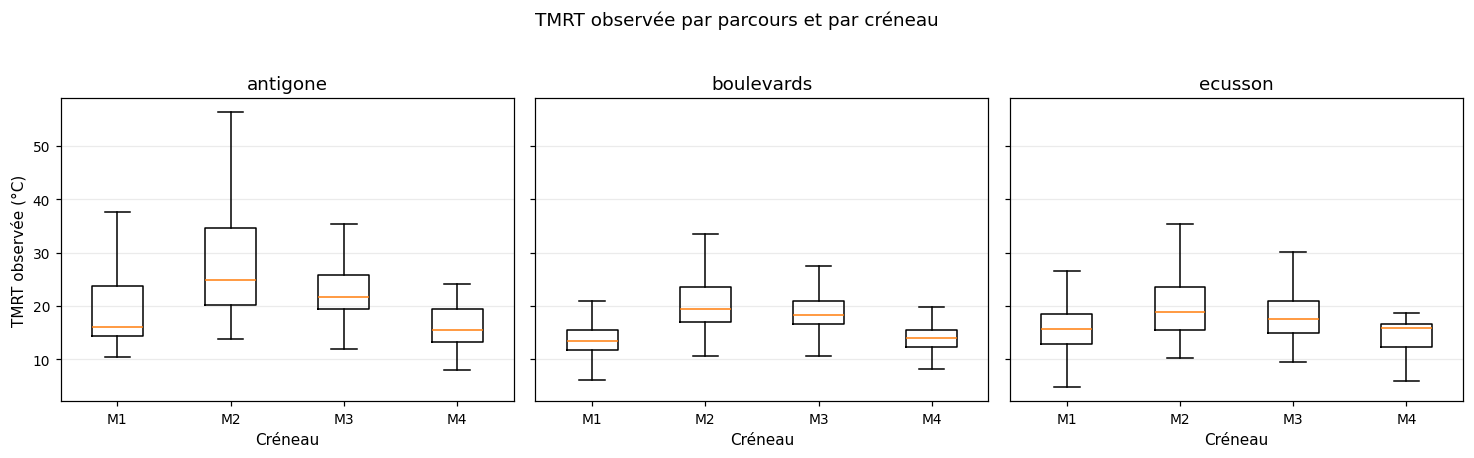

Figure enregistrée : prediction\figures\prediction_data\tmrt_by_track_mslot.png


In [4]:
if analysis_df.empty or not {"track_id", "M_slot", "tmrt"}.issubset(analysis_df.columns):
    print("Colonnes track_id, M_slot ou tmrt absentes.")
else:
    tracks = ordered_existing(analysis_df["track_id"].dropna().unique(), TRACK_ORDER)
    slots = ordered_existing(analysis_df["M_slot"].dropna().unique(), MSLOT_ORDER)
    fig, axes = plt.subplots(1, len(tracks), figsize=(4.5 * len(tracks), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, track in zip(axes, tracks):
        part = analysis_df[analysis_df["track_id"].eq(track)]
        values = [part.loc[part["M_slot"].eq(slot), "tmrt"].dropna() for slot in slots]
        ax.boxplot(values, labels=slots, showfliers=False)
        ax.set_title(track)
        ax.set_xlabel("Cr\u00e9neau")
        ax.grid(axis="y", alpha=0.25)

    axes[0].set_ylabel("TMRT observ\u00e9e (\u00b0C)")
    fig.suptitle("TMRT observ\u00e9e par parcours et par cr\u00e9neau", y=1.03)
    save_figure(fig, FIG_PRED_DATA / "tmrt_by_track_mslot.png")


## 2. \u00c9valuation du mod\u00e8le

Ces figures servent \u00e0 comparer les performances selon la mani\u00e8re de s\u00e9parer les donn\u00e9es. Le split al\u00e9atoire reste utile comme rep\u00e8re, mais les splits par passage, section, date ou parcours donnent une lecture plus prudente de la g\u00e9n\u00e9ralisation.


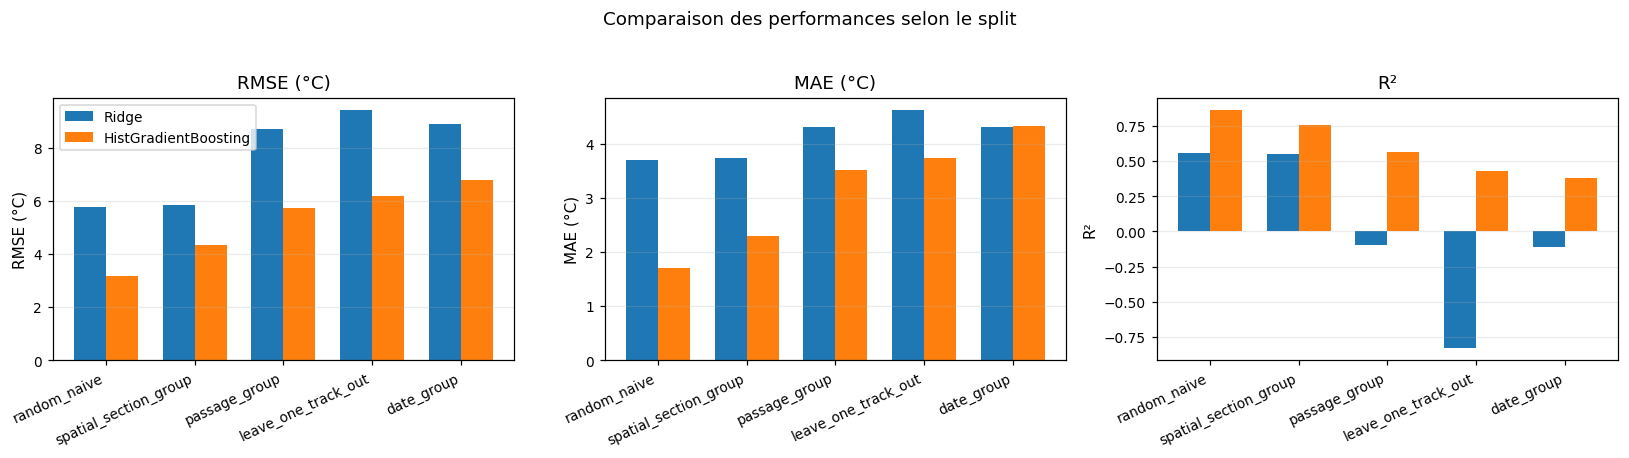

Figure enregistrée : prediction\figures\eval\metrics_comparison_splits.png


In [5]:
plot_metrics = model_comparison.copy()
if plot_metrics.empty and not metrics_all.empty:
    plot_metrics = (
        metrics_all.groupby(["feature_set", "model", "split"], as_index=False)
        .agg(
            rmse_mean=("rmse", "mean"),
            mae_mean=("mae", "mean"),
            r2_mean=("r2", "mean"),
        )
    )

if plot_metrics.empty:
    print("Aucune table de comparaison des mod\u00e8les disponible.")
else:
    plot_metrics = plot_metrics[plot_metrics["feature_set"].eq("feature_set_generalizable")].copy()
    split_order = [s for s in SPLIT_ORDER if s in set(plot_metrics["split"])]
    models = [m for m in ["Ridge", "HistGradientBoosting"] if m in set(plot_metrics["model"])]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    specs = [
        ("rmse_mean", "RMSE (\u00b0C)"),
        ("mae_mean", "MAE (\u00b0C)"),
        ("r2_mean", "R\u00b2"),
    ]
    x = np.arange(len(split_order))
    width = 0.36 if len(models) > 1 else 0.55
    colors = [BLUE, ORANGE]

    for ax, (metric, label) in zip(axes, specs):
        for i, model in enumerate(models):
            sub = plot_metrics[plot_metrics["model"].eq(model)].set_index("split")
            vals = [sub.loc[s, metric] if s in sub.index else np.nan for s in split_order]
            offset = (i - (len(models) - 1) / 2) * width
            ax.bar(x + offset, vals, width=width, label=model, color=colors[i % len(colors)])
        ax.set_xticks(x)
        ax.set_xticklabels(split_order, rotation=25, ha="right")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(axis="y", alpha=0.25)

    axes[0].legend()
    fig.suptitle("Comparaison des performances selon le split", y=1.03)
    save_figure(fig, FIG_EVAL / "metrics_comparison_splits.png")


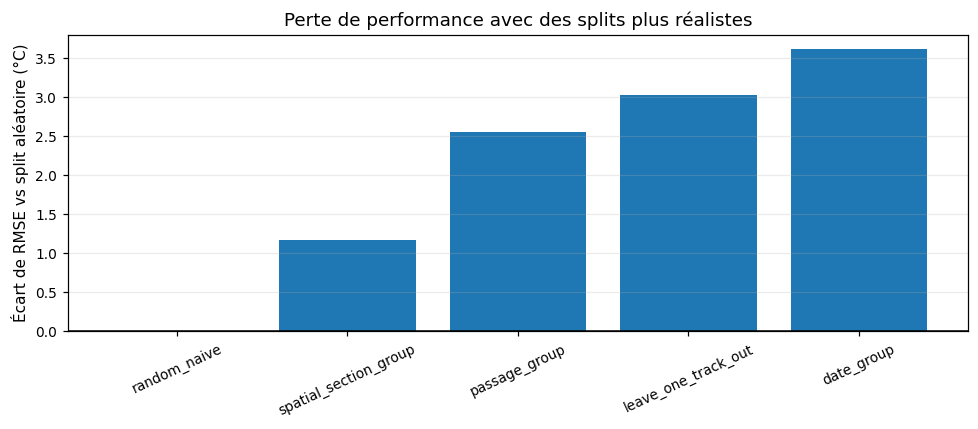

Figure enregistrée : prediction\figures\eval\generalization_gap_by_split.png


In [6]:
if plot_metrics.empty:
    print("Comparaison des splits non disponible.")
else:
    hgb = plot_metrics[plot_metrics["model"].eq("HistGradientBoosting")].set_index("split")
    if "random_naive" not in hgb.index:
        print("Le split random_naive est absent : impossible de calculer l'\u00e9cart de g\u00e9n\u00e9ralisation.")
    else:
        split_order = [s for s in SPLIT_ORDER if s in hgb.index]
        baseline = hgb.loc["random_naive", "rmse_mean"]
        gaps = [hgb.loc[s, "rmse_mean"] - baseline for s in split_order]

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.bar(split_order, gaps, color=BLUE)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_ylabel("\u00c9cart de RMSE vs split al\u00e9atoire (\u00b0C)")
        ax.set_title("Perte de performance avec des splits plus r\u00e9alistes")
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)

        save_figure(fig, FIG_EVAL / "generalization_gap_by_split.png")


Pas de fichier predictions_by_split.csv : la figure utilise les prédictions disponibles dans tmrt_pred_report.


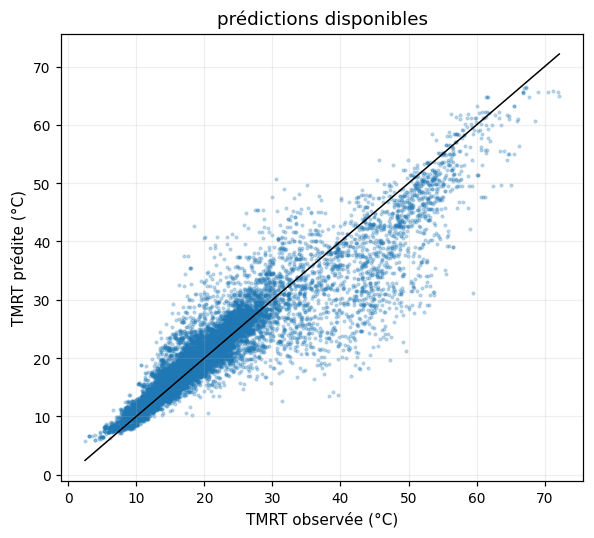

Figure enregistrée : prediction\figures\eval\predicted_vs_observed_by_split.png
Copie enregistrée : prediction\figures\eval\predicted_vs_observed_available_predictions.png


In [7]:
split_predictions_path = EVAL_DIR / "predictions_by_split.csv"

if split_predictions_path.exists():
    pred_split = pd.read_csv(split_predictions_path)
    numeric_columns(pred_split, ["tmrt", "tmrt_pred"])
    pred_split = pred_split.dropna(subset=["tmrt", "tmrt_pred", "split"])
else:
    pred_split = test_rows if not test_rows.empty else analysis_df
    pred_split = pred_split.dropna(subset=["tmrt", "tmrt_pred"]).copy()
    pred_split["split"] = "pr\u00e9dictions disponibles"
    print("Pas de fichier predictions_by_split.csv : la figure utilise les pr\u00e9dictions disponibles dans tmrt_pred_report.")

if pred_split.empty or not {"tmrt", "tmrt_pred", "split"}.issubset(pred_split.columns):
    print("Donn\u00e9es insuffisantes pour le nuage pr\u00e9diction vs observation.")
else:
    splits = list(pred_split["split"].dropna().unique())[:4]
    ncols = min(2, len(splits))
    nrows = math.ceil(len(splits) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), squeeze=False)

    for ax, split in zip(axes.ravel(), splits):
        part = pred_split[pred_split["split"].eq(split)]
        sample = part.sample(n=min(25000, len(part)), random_state=42)
        ax.scatter(sample["tmrt"], sample["tmrt_pred"], s=3, alpha=0.25, color=BLUE)
        low = min(sample["tmrt"].min(), sample["tmrt_pred"].min())
        high = max(sample["tmrt"].max(), sample["tmrt_pred"].max())
        ax.plot([low, high], [low, high], color="black", linewidth=1)
        ax.set_title(str(split))
        ax.set_xlabel("TMRT observ\u00e9e (\u00b0C)")
        ax.set_ylabel("TMRT pr\u00e9dite (\u00b0C)")
        ax.grid(alpha=0.2)

    for ax in axes.ravel()[len(splits):]:
        ax.axis("off")

    extra_paths = [] if split_predictions_path.exists() else [FIG_EVAL / "predicted_vs_observed_available_predictions.png"]
    save_figure(fig, FIG_EVAL / "predicted_vs_observed_by_split.png", extra_paths=extra_paths)


## 3. R\u00e9sidus et biais

On regarde maintenant les erreurs elles-m\u00eames. Une bonne moyenne globale peut masquer des biais par date, par cr\u00e9neau ou par parcours ; ces figures servent \u00e0 rep\u00e9rer ces cas.


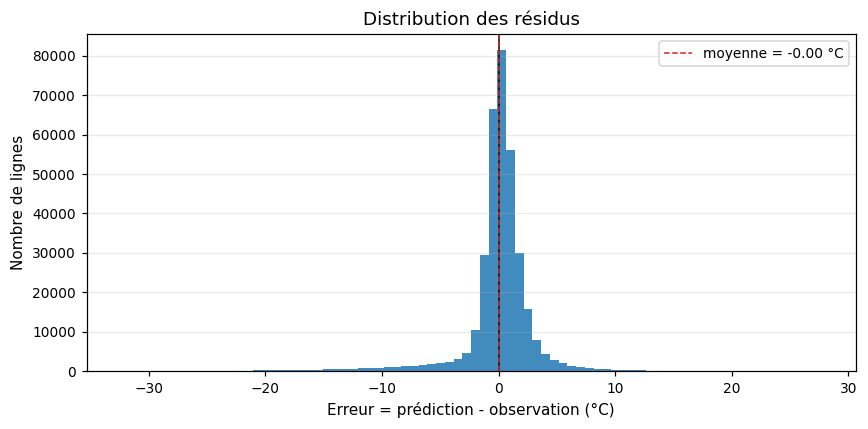

Figure enregistrée : prediction\figures\biais\residual_distribution.png


In [8]:
residual_df = test_rows if not test_rows.empty else analysis_df

if residual_df.empty or "err" not in residual_df.columns:
    print("Aucune colonne err disponible.")
else:
    errors = residual_df["err"].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(errors, bins=80, color=BLUE, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(errors.mean(), color=RED, linestyle="--", linewidth=1, label=f"moyenne = {errors.mean():.2f} \u00b0C")
    ax.set_xlabel("Erreur = pr\u00e9diction - observation (\u00b0C)")
    ax.set_ylabel("Nombre de lignes")
    ax.set_title("Distribution des r\u00e9sidus")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    save_figure(fig, FIG_BIAS / "residual_distribution.png")


C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\322899532.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=slots, showfliers=False)
C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\322899532.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=slots, showfliers=False)
C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\322899532.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=slots, showfliers=False)


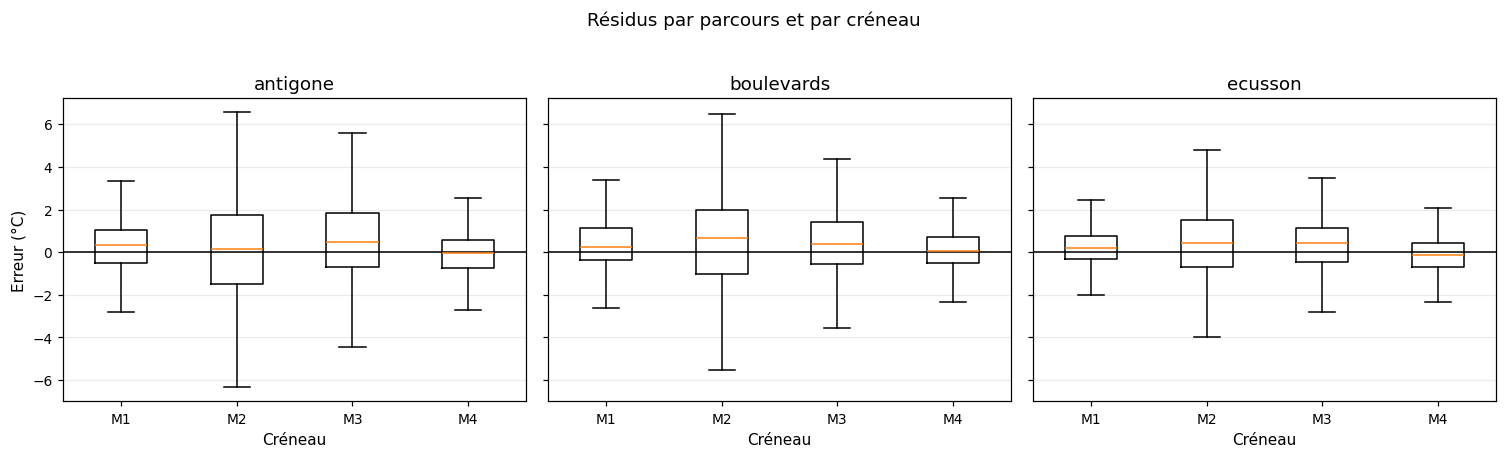

Figure enregistrée : prediction\figures\eval\residuals_by_track_mslot.png


In [9]:
if residual_df.empty or not {"track_id", "M_slot", "err"}.issubset(residual_df.columns):
    print("Colonnes insuffisantes pour les r\u00e9sidus par parcours et cr\u00e9neau.")
else:
    tracks = ordered_existing(residual_df["track_id"].dropna().unique(), TRACK_ORDER)
    slots = ordered_existing(residual_df["M_slot"].dropna().unique(), MSLOT_ORDER)
    fig, axes = plt.subplots(1, len(tracks), figsize=(4.6 * len(tracks), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, track in zip(axes, tracks):
        part = residual_df[residual_df["track_id"].eq(track)]
        values = [part.loc[part["M_slot"].eq(slot), "err"].dropna() for slot in slots]
        ax.boxplot(values, labels=slots, showfliers=False)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(track)
        ax.set_xlabel("Cr\u00e9neau")
        ax.grid(axis="y", alpha=0.25)

    axes[0].set_ylabel("Erreur (\u00b0C)")
    fig.suptitle("R\u00e9sidus par parcours et par cr\u00e9neau", y=1.03)
    save_figure(fig, FIG_EVAL / "residuals_by_track_mslot.png")


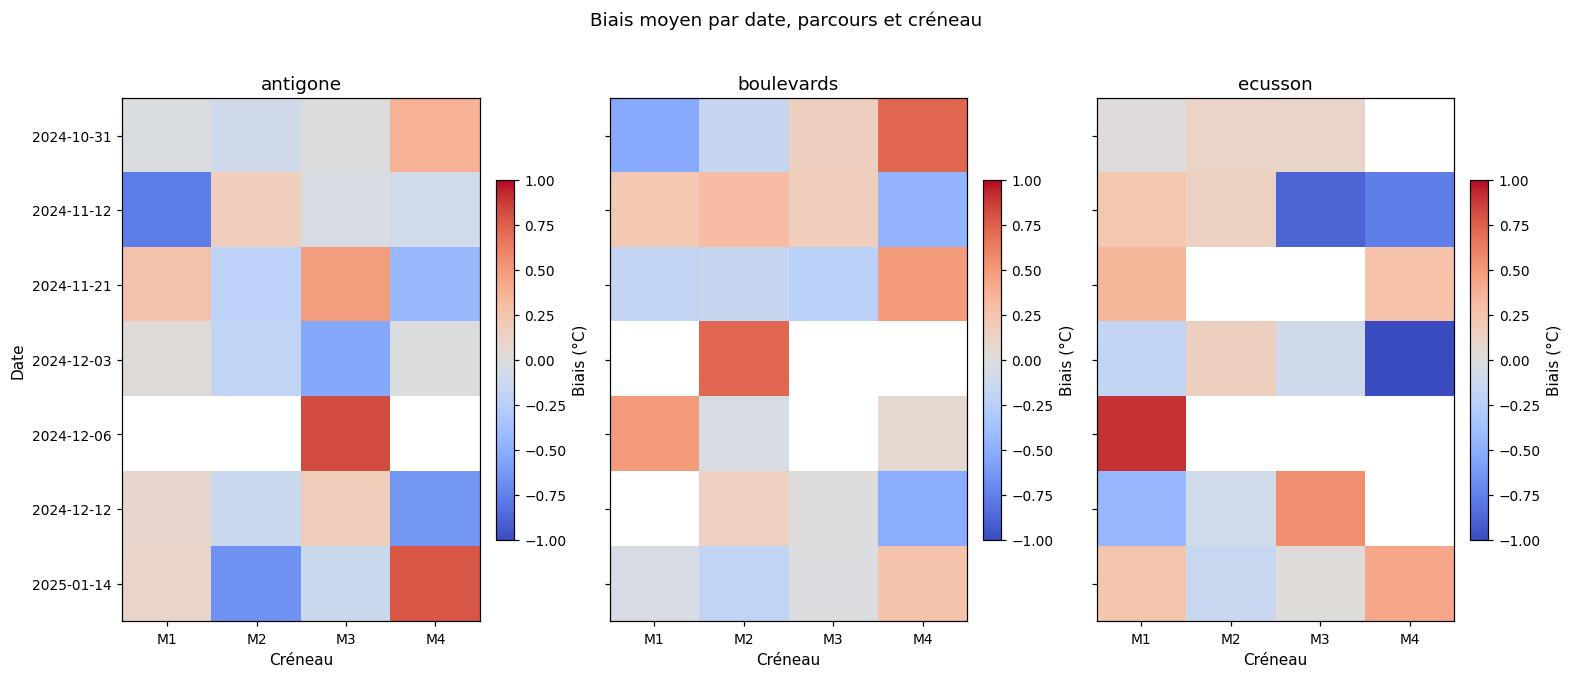

Figure enregistrée : prediction\figures\biais\bias_by_date_mslot_track.png


In [10]:
if analysis_df.empty or not {"track_id", "date", "M_slot", "err"}.issubset(analysis_df.columns):
    print("Colonnes insuffisantes pour le biais par date, cr\u00e9neau et parcours.")
else:
    bias_grid = (
        analysis_df.dropna(subset=["track_id", "date", "M_slot", "err"])
        .groupby(["track_id", "date", "M_slot"], as_index=False)["err"]
        .mean()
    )
    tracks = ordered_existing(bias_grid["track_id"].unique(), TRACK_ORDER)
    vmax = np.nanpercentile(np.abs(bias_grid["err"]), 95)
    vmax = max(1.0, min(float(vmax), 8.0))

    fig, axes = plt.subplots(1, len(tracks), figsize=(4.8 * len(tracks), 6), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, track in zip(axes, tracks):
        part = bias_grid[bias_grid["track_id"].eq(track)]
        pivot = part.pivot(index="date", columns="M_slot", values="err")
        pivot = pivot.reindex(columns=[s for s in MSLOT_ORDER if s in pivot.columns]).sort_index()
        im = ax.imshow(pivot.values, cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(track)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("Cr\u00e9neau")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Biais (\u00b0C)")

    axes[0].set_ylabel("Date")
    fig.suptitle("Biais moyen par date, parcours et cr\u00e9neau", y=1.02)
    save_figure(fig, FIG_BIAS / "bias_by_date_mslot_track.png")


## 4. Zones o\u00f9 le mod\u00e8le est fragile

Ces figures aident \u00e0 identifier les situations les plus difficiles : valeurs de TMRT extr\u00eames, groupes avec forte erreur et localisation approximative des r\u00e9sidus.


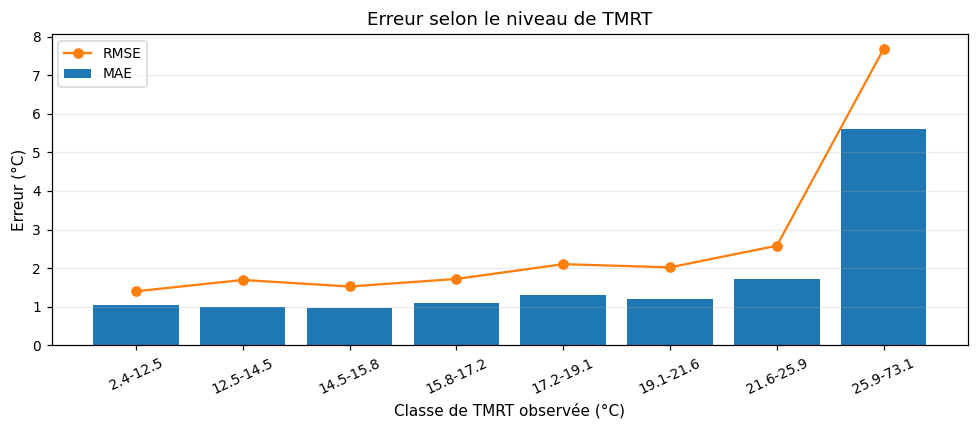

Figure enregistrée : prediction\figures\model_analysis\error_by_tmrt_range.png


In [11]:
if residual_df.empty or not {"tmrt", "err"}.issubset(residual_df.columns):
    print("Colonnes tmrt et err absentes.")
else:
    tmp = residual_df.dropna(subset=["tmrt", "err"]).copy()
    tmp["classe_tmrt"] = pd.qcut(tmp["tmrt"], q=8, duplicates="drop")
    err_bins = (
        tmp.groupby("classe_tmrt", observed=True)
        .agg(mae=("err", lambda x: np.mean(np.abs(x))), rmse=("err", lambda x: np.sqrt(np.mean(x**2))))
        .reset_index()
    )
    labels = [f"{interval.left:.1f}-{interval.right:.1f}" for interval in err_bins["classe_tmrt"]]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(labels, err_bins["mae"], color=BLUE, label="MAE")
    ax.plot(labels, err_bins["rmse"], color=ORANGE, marker="o", label="RMSE")
    ax.set_xlabel("Classe de TMRT observ\u00e9e (\u00b0C)")
    ax.set_ylabel("Erreur (\u00b0C)")
    ax.set_title("Erreur selon le niveau de TMRT")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    save_figure(fig, FIG_MODEL / "error_by_tmrt_range.png")


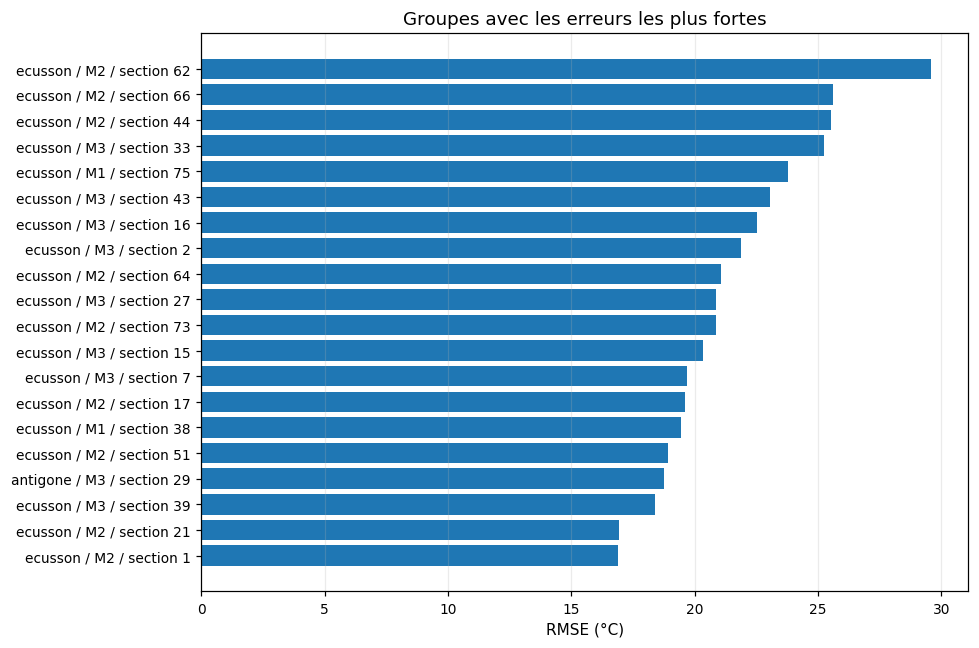

Figure enregistrée : prediction\figures\model_analysis\worst_groups_rmse.png


In [12]:
if group_errors.empty or not {"track_id", "M_slot", "section_id", "rmse"}.issubset(group_errors.columns):
    print("Table des erreurs par groupe absente ou incompl\u00e8te.")
else:
    top = group_errors.sort_values("rmse", ascending=False).head(20).copy()
    labels = top.apply(lambda r: f"{r['track_id']} / {r['M_slot']} / section {int(r['section_id'])}", axis=1)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(labels[::-1], top["rmse"][::-1], color=BLUE)
    ax.set_xlabel("RMSE (\u00b0C)")
    ax.set_title("Groupes avec les erreurs les plus fortes")
    ax.grid(axis="x", alpha=0.25)

    save_figure(fig, FIG_MODEL / "worst_groups_rmse.png")


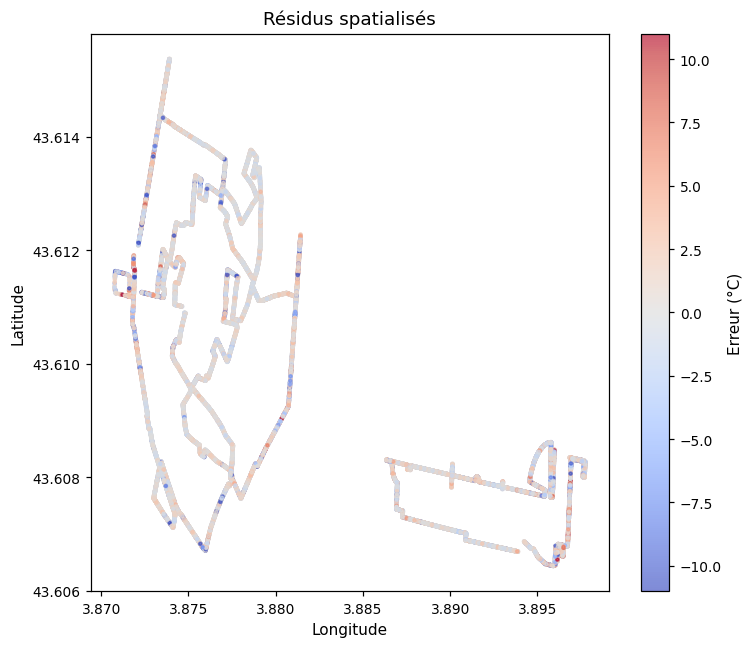

Figure enregistrée : prediction\figures\model_analysis\spatial_residual_map.png


In [13]:
lon_col = "lon_map" if "lon_map" in analysis_df.columns else "lon_ontrack" if "lon_ontrack" in analysis_df.columns else None
lat_col = "lat_map" if "lat_map" in analysis_df.columns else "lat_ontrack" if "lat_ontrack" in analysis_df.columns else None

if analysis_df.empty or lon_col is None or lat_col is None or "err" not in analysis_df.columns:
    print("Coordonn\u00e9es ou r\u00e9sidus absents pour la carte des erreurs.")
else:
    plot_df = analysis_df.dropna(subset=[lon_col, lat_col, "err"]).sample(
        n=min(30000, len(analysis_df.dropna(subset=[lon_col, lat_col, "err"]))),
        random_state=42,
    )
    vmax = np.nanpercentile(np.abs(plot_df["err"]), 98)
    vmax = max(1.0, min(float(vmax), 12.0))

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(
        plot_df[lon_col],
        plot_df[lat_col],
        c=plot_df["err"],
        s=4,
        alpha=0.65,
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("R\u00e9sidus spatialis\u00e9s")
    plt.colorbar(sc, ax=ax, label="Erreur (\u00b0C)")

    save_figure(fig, FIG_MODEL / "spatial_residual_map.png")


## 5. Structure non ind\u00e9pendante des observations

Les lignes PICOPATT sont nombreuses, mais elles proviennent de passages successifs sur les m\u00eames parcours. Ces figures rappellent que les observations sont structur\u00e9es par blocs spatiaux et temporels.


C:\Users\antoc\AppData\Local\Temp\ipykernel_69320\3574143089.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=tracks, showfliers=False)


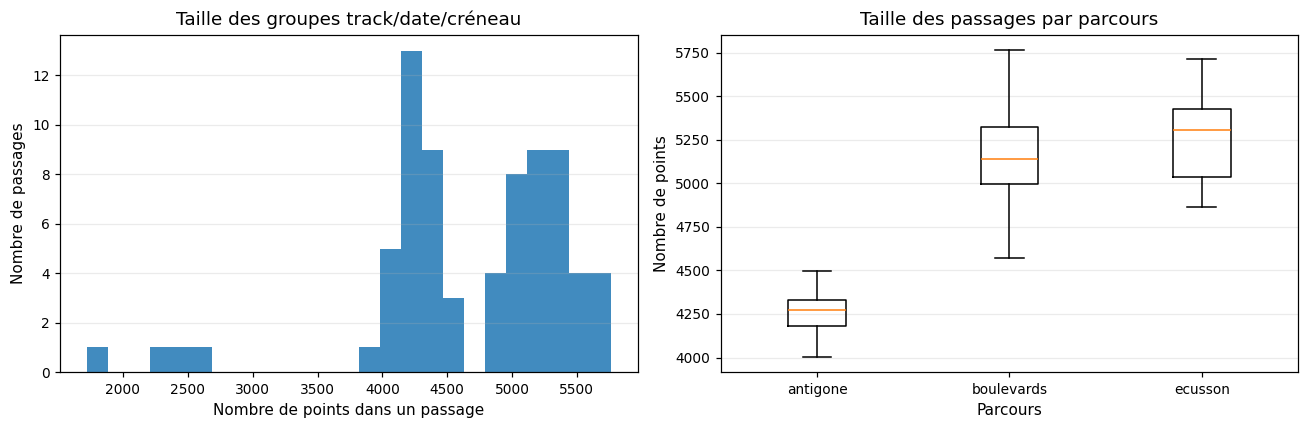

Figure enregistrée : prediction\figures\no_iid\points_by_group.png


,n_points
count,73.000000
mean,4675.082192
std,786.283289
min,1719.000000
25%,4243.000000
50%,4865.000000
75%,5257.000000
max,5765.000000


In [14]:
if analysis_df.empty or not {"track_id", "date", "M_slot"}.issubset(analysis_df.columns):
    print("Colonnes insuffisantes pour compter les groupes de passage.")
else:
    counts = (
        analysis_df.groupby(["track_id", "date", "M_slot"])
        .size()
        .reset_index(name="n_points")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(counts["n_points"], bins=25, color=BLUE, alpha=0.85)
    axes[0].set_xlabel("Nombre de points dans un passage")
    axes[0].set_ylabel("Nombre de passages")
    axes[0].set_title("Taille des groupes track/date/cr\u00e9neau")
    axes[0].grid(axis="y", alpha=0.25)

    if "track_id" in counts.columns:
        tracks = ordered_existing(counts["track_id"].unique(), TRACK_ORDER)
        data = [counts.loc[counts["track_id"].eq(track), "n_points"] for track in tracks]
        axes[1].boxplot(data, labels=tracks, showfliers=False)
        axes[1].set_xlabel("Parcours")
        axes[1].set_ylabel("Nombre de points")
        axes[1].set_title("Taille des passages par parcours")
        axes[1].grid(axis="y", alpha=0.25)
    else:
        axes[1].axis("off")

    save_figure(fig, FIG_NO_IID / "points_by_group.png")
    display(counts["n_points"].describe().to_frame("n_points"))


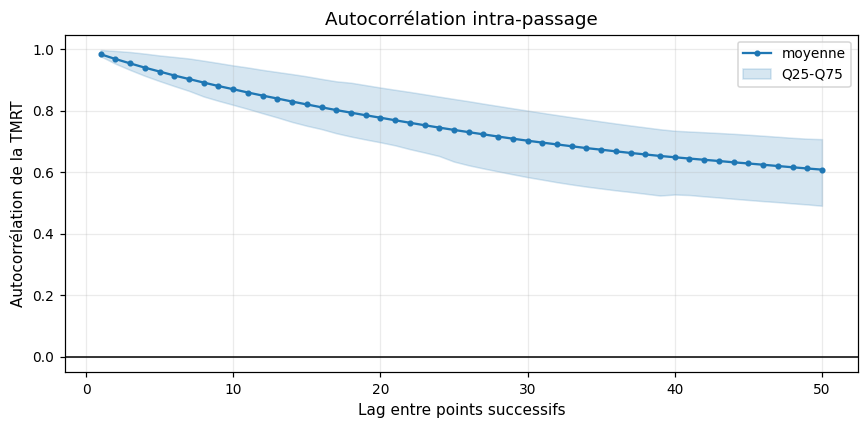

Figure enregistrée : prediction\figures\no_iid\autocorrelation_tmrt_lag.png


In [15]:
def autocorr(values, lag):
    if len(values) <= lag:
        return np.nan
    a = values[:-lag]
    b = values[lag:]
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

if analysis_df.empty or not {"track_id", "date", "M_slot", "tmrt"}.issubset(analysis_df.columns):
    print("Colonnes insuffisantes pour l'autocorr\u00e9lation.")
else:
    sort_cols = [c for c in ["uid", "section_id", "point_id"] if c in analysis_df.columns]
    lags = np.arange(1, 51)
    rows = []

    for _, group in analysis_df.dropna(subset=["tmrt"]).groupby(["track_id", "date", "M_slot"]):
        if sort_cols:
            group = group.sort_values(sort_cols)
        values = group["tmrt"].to_numpy(dtype=float)
        if len(values) < 20:
            continue
        for lag in lags:
            rows.append({"lag": lag, "corr": autocorr(values, lag)})

    corr_df = pd.DataFrame(rows).dropna()
    if corr_df.empty:
        print("Autocorr\u00e9lation non calculable sur les groupes disponibles.")
    else:
        summary = (
            corr_df.groupby("lag")["corr"]
            .agg(mean="mean", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
            .reset_index()
        )

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(summary["lag"], summary["mean"], color=BLUE, marker="o", markersize=3, label="moyenne")
        ax.fill_between(summary["lag"], summary["q25"], summary["q75"], color=BLUE, alpha=0.18, label="Q25-Q75")
        ax.axhline(0, color="black", linewidth=1)
        ax.set_xlabel("Lag entre points successifs")
        ax.set_ylabel("Autocorr\u00e9lation de la TMRT")
        ax.set_title("Autocorr\u00e9lation intra-passage")
        ax.grid(alpha=0.25)
        ax.legend()

        save_figure(fig, FIG_NO_IID / "autocorrelation_tmrt_lag.png")


## Figures pour le rapport depuis `data/processed/results`

Cette section repart des CSV exportes dans `data/processed/results`. Elle produit des figures directement utilisables dans le rapport S2 et les copie aussi dans `rapport/s2/Images/Modelisation/`.


In [ ]:
RESULTS_DIR = ROOT / "data" / "processed" / "results"
FIG_RESULTS = FIG_MODEL / "results_csv"
REPORT_MODEL_FIG = ROOT / "rapport" / "s2" / "Images" / "Modelisation"
GREEN = "#2ca02c"

for folder in [FIG_RESULTS, REPORT_MODEL_FIG]:
    folder.mkdir(parents=True, exist_ok=True)

TRACK_ORDER = ["antigone", "ecusson", "boulevards"]
TRACK_LABELS = {
    "antigone": "Antigone",
    "ecusson": "Ecusson",
    "boulevards": "Boulevards",
}
MSLOT_ORDER = ["M1", "M2", "M3", "M4"]


def read_results_csv(name, **kwargs):
    return read_csv_if_exists(RESULTS_DIR / name, **kwargs)


def save_results_figure(fig, name):
    save_figure(
        fig,
        FIG_RESULTS / name,
        extra_paths=[REPORT_MODEL_FIG / name],
    )


def rmse_array(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2)))

In [ ]:
# Comparaison initiale des jeux de variables
initial_df = read_results_csv("tmrt_pred_global_results.csv")
if not initial_df.empty:
    initial_df = numeric_columns(initial_df.copy(), ["rmse", "mae", "r2"])
    order = ["MF_only", "MF_plus_AE_PCA10", "MF_plus_AE_raw64"]
    labels = {
        "MF_only": "MF seul",
        "MF_plus_AE_PCA10": "MF + AE ACP10",
        "MF_plus_AE_raw64": "MF + AE64",
    }
    plot_df = (
        initial_df.set_index("set")
        .reindex(order)
        .dropna(subset=["rmse", "mae", "r2"], how="all")
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(8.5, 4.4))
    x = np.arange(len(plot_df))
    width = 0.32
    ax1.bar(x - width / 2, plot_df["rmse"], width, color=BLUE, label="RMSE")
    ax1.bar(x + width / 2, plot_df["mae"], width, color=ORANGE, label="MAE")
    ax1.set_ylabel("Erreur (deg C)")
    ax1.set_xticks(x)
    ax1.set_xticklabels([labels.get(s, s) for s in plot_df["set"]])
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(x, plot_df["r2"], color=GREEN, marker="o", linewidth=2, label="R2")
    ax2.set_ylabel("R2")
    ax2.set_ylim(0, max(0.75, float(plot_df["r2"].max()) + 0.08))
    ax2.legend(loc="upper right")

    ax1.set_title("Apport des embeddings AlphaEarth")
    save_results_figure(fig, "alphaearth_sets_comparison_results.png")

# Ecart entrainement / validation sur le split spatial fixe
spatial_grid_df = read_results_csv("tmrt_grid_search_spatial_results.csv")
if not spatial_grid_df.empty:
    spatial_grid_df = numeric_columns(spatial_grid_df.copy(), ["rmse_train", "rmse_val"])
    plot_df = spatial_grid_df.sort_values("rmse_val").head(12).reset_index(drop=True)
    x = np.arange(len(plot_df)) + 1

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.plot(x, plot_df["rmse_train"], marker="o", color=GREEN, label="Entrainement")
    ax.plot(x, plot_df["rmse_val"], marker="o", color=RED, label="Validation")
    ax.set_xlabel("Configurations testees, triees par RMSE validation")
    ax.set_ylabel("RMSE (deg C)")
    ax.set_title("Grid search sur split spatial fixe")
    ax.set_xticks(x)
    ax.grid(alpha=0.25)
    ax.legend()
    save_results_figure(fig, "spatial_gridsearch_gap_results.png")

# Robustesse du split spatio-temporel
repeat_df = read_results_csv("tmrt_spatiotemporal_repeated_split_results.csv")
if not repeat_df.empty:
    repeat_df = numeric_columns(repeat_df.copy(), ["rmse", "mae", "r2", "random_state"])
    pivot = repeat_df.pivot(index="random_state", columns="split", values="rmse").sort_index()

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    if "validation" in pivot.columns:
        ax.plot(pivot.index, pivot["validation"], marker="o", color=BLUE, label="Validation")
        ax.axhline(pivot["validation"].mean(), color=BLUE, linestyle="--", linewidth=1, alpha=0.7)
    if "test" in pivot.columns:
        ax.plot(pivot.index, pivot["test"], marker="o", color=ORANGE, label="Test")
        ax.axhline(pivot["test"].mean(), color=ORANGE, linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("random_state du split")
    ax.set_ylabel("RMSE (deg C)")
    ax.set_title("Robustesse du split spatio-temporel")
    ax.grid(alpha=0.25)
    ax.legend()
    save_results_figure(fig, "split_robustness_rmse_results.png")

# Synthese chronologique des resultats
rows = []
if not initial_df.empty:
    row = initial_df[initial_df["set"].eq("MF_only")]
    if not row.empty:
        rows.append({"etape": "MF seul", "rmse": float(row.iloc[0]["rmse"]), "mae": float(row.iloc[0]["mae"]), "r2": float(row.iloc[0]["r2"])})
    row = initial_df[initial_df["set"].eq("MF_plus_AE_raw64")]
    if not row.empty:
        rows.append({"etape": "MF + AE64", "rmse": float(row.iloc[0]["rmse"]), "mae": float(row.iloc[0]["mae"]), "r2": float(row.iloc[0]["r2"])})

improved_df = read_results_csv("tmrt_pred_improved_results.csv")
if not improved_df.empty:
    improved_df = numeric_columns(improved_df.copy(), ["rmse", "mae", "r2"])
    row = improved_df[improved_df["set"].eq("4_MF+AE64+extra_tuned")]
    if not row.empty:
        rows.append({"etape": "HistGBR enrichi", "rmse": float(row.iloc[0]["rmse"]), "mae": float(row.iloc[0]["mae"]), "r2": float(row.iloc[0]["r2"])})

st_df = read_results_csv("tmrt_spatiotemporal_split_metrics.csv")
if not st_df.empty:
    st_df = numeric_columns(st_df.copy(), ["rmse", "mae", "r2"])
    row = st_df[st_df["split"].eq("test")]
    if not row.empty:
        rows.append({"etape": "HistGBR spatio-temporel", "rmse": float(row.iloc[0]["rmse"]), "mae": float(row.iloc[0]["mae"]), "r2": float(row.iloc[0]["r2"])})

cat_eval_df = read_results_csv("tmrt_catboost_eval.csv")
if not cat_eval_df.empty:
    cat_eval_df = numeric_columns(cat_eval_df.copy(), ["rmse", "mae", "r2"])
    row = cat_eval_df[cat_eval_df["split"].eq("test")]
    if not row.empty:
        rows.append({"etape": "CatBoost", "rmse": float(row.iloc[0]["rmse"]), "mae": float(row.iloc[0]["mae"]), "r2": float(row.iloc[0]["r2"])})

progress_df = pd.DataFrame(rows)
if not progress_df.empty:
    fig, ax1 = plt.subplots(figsize=(9.2, 4.6))
    x = np.arange(len(progress_df))
    ax1.bar(x, progress_df["rmse"], color=BLUE, alpha=0.88, label="RMSE")
    ax1.plot(x, progress_df["mae"], color=ORANGE, marker="o", linewidth=2, label="MAE")
    ax1.set_ylabel("Erreur (deg C)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(progress_df["etape"], rotation=18, ha="right")
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(x, progress_df["r2"], color=GREEN, marker="s", linewidth=2, label="R2")
    ax2.set_ylabel("R2")
    ax2.set_ylim(0, max(0.8, float(progress_df["r2"].max()) + 0.08))
    ax2.legend(loc="upper right")
    ax1.set_title("Evolution des resultats de prediction")
    save_results_figure(fig, "model_progression_results.png")

# Importance des variables CatBoost
fi_df = read_results_csv("tmrt_catboost_feature_importance.csv")
if not fi_df.empty:
    fi_df = numeric_columns(fi_df.copy(), ["importance"])
    top = fi_df.sort_values("importance", ascending=False).head(20).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8.2, 6.0))
    ax.barh(top["feature"], top["importance"], color=BLUE)
    ax.set_xlabel("Importance CatBoost")
    ax.set_title("Variables les plus utilisees par CatBoost")
    ax.grid(axis="x", alpha=0.25)
    save_results_figure(fig, "catboost_feature_importance_top20_results.png")

# Erreur CatBoost par parcours et par creneau
cat_test_df = read_results_csv("tmrt_catboost_pred_test.csv")
if not cat_test_df.empty:
    cat_test_df = numeric_columns(cat_test_df.copy(), ["tmrt", "tmrt_pred", "err"])
    heat_df = (
        cat_test_df.groupby(["track_id", "M_slot"])["err"]
        .agg(rmse=rmse_array, mae=lambda s: float(np.mean(np.abs(s))))
        .reset_index()
    )
    pivot = (
        heat_df.pivot(index="track_id", columns="M_slot", values="rmse")
        .reindex(index=TRACK_ORDER, columns=MSLOT_ORDER)
    )

    fig, ax = plt.subplots(figsize=(7.6, 3.8))
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad("#eeeeee")
    masked_values = np.ma.masked_invalid(pivot.values.astype(float))
    im = ax.imshow(masked_values, cmap=cmap, aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([TRACK_LABELS.get(v, v) for v in pivot.index])
    ax.set_xlabel("Creneau")
    ax.set_ylabel("Parcours")
    ax.set_title("RMSE CatBoost par parcours et creneau")
    vmax = np.nanmax(pivot.values)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.iloc[i, j]
            if pd.isna(value):
                ax.text(j, i, "n.d.", ha="center", va="center", color="#555555", fontsize=8)
            else:
                color = "white" if value > vmax * 0.68 else "black"
                ax.text(j, i, f"{value:.1f}", ha="center", va="center", color=color, fontsize=9)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("RMSE (deg C)")
    save_results_figure(fig, "catboost_error_by_track_mslot_results.png")

    bins = [-np.inf, 15, 20, 25, 30, 35, 40, np.inf]
    labels = ["<15", "15-20", "20-25", "25-30", "30-35", "35-40", ">40"]
    cat_test_df["tmrt_level"] = pd.cut(cat_test_df["tmrt"], bins=bins, labels=labels, include_lowest=True)
    level_df = (
        cat_test_df.dropna(subset=["tmrt_level", "err"])
        .groupby("tmrt_level", observed=False)["err"]
        .agg(rmse=rmse_array, mae=lambda s: float(np.mean(np.abs(s))), n="size")
        .reindex(labels)
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(8.3, 4.2))
    x = np.arange(len(level_df))
    ax1.bar(x, level_df["mae"], color=ORANGE, alpha=0.85, label="MAE")
    ax1.plot(x, level_df["rmse"], color=RED, marker="o", linewidth=2, label="RMSE")
    ax1.set_xticks(x)
    ax1.set_xticklabels(level_df["tmrt_level"])
    ax1.set_xlabel("tmrt observee (deg C)")
    ax1.set_ylabel("Erreur (deg C)")
    ax1.set_title("Erreur selon le niveau de tmrt observee")
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(x, level_df["n"], color=BLUE, marker="s", linewidth=1.5, alpha=0.6, label="Lignes")
    ax2.set_ylabel("Nombre de lignes")
    ax2.legend(loc="upper right")
    save_results_figure(fig, "catboost_error_by_tmrt_level_results.png")

## Figures produites

La cellule suivante liste les fichiers enregistr\u00e9s pendant l'ex\u00e9cution du notebook.


In [16]:
if GENERATED_FIGURES:
    generated = pd.DataFrame({"figure": [str(rel(path)) for path in GENERATED_FIGURES]})
    display(generated)
else:
    print("Aucune figure n'a encore \u00e9t\u00e9 g\u00e9n\u00e9r\u00e9e dans cette session.")


,figure
0,prediction\figures\prediction_data\prediction_dat...
1,prediction\figures\prediction_data\tmrt_by_track_...
2,prediction\figures\eval\metrics_comparison_splits...
3,prediction\figures\eval\generalization_gap_by_spl...
4,prediction\figures\eval\predicted_vs_observed_by_...
5,prediction\figures\eval\predicted_vs_observed_ava...
6,prediction\figures\biais\residual_distribution.png
7,prediction\figures\eval\residuals_by_track_mslot.png
8,prediction\figures\biais\bias_by_date_mslot_track...
9,prediction\figures\model_analysis\error_by_tmrt_r...
